<a href="https://colab.research.google.com/github/opeyemijanet/Nigeria-Inflation-Time-Series-Analysis/blob/main/Nigeria_Inflation_Analysis_2016_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/ObservationData_jmmtfce.csv")

In [4]:
df.head()

,location,item,indicator,measure,Unit,Date,Value
0,Nigeria,All Items,Composite Consumer Price Index,"Index, Nov 2009 = 100","Index, Nov 2009 = 100",2015M1,165.77
1,Nigeria,All Items,Composite Consumer Price Index,"Index, Nov 2009 = 100","Index, Nov 2009 = 100",2015M2,166.90
2,Nigeria,All Items,Composite Consumer Price Index,"Index, Nov 2009 = 100","Index, Nov 2009 = 100",2015M3,168.42
3,Nigeria,All Items,Composite Consumer Price Index,"Index, Nov 2009 = 100","Index, Nov 2009 = 100",2015M4,169.71
4,Nigeria,All Items,Composite Consumer Price Index,"Index, Nov 2009 = 100","Index, Nov 2009 = 100",2015M5,171.58


In [5]:
df.shape

(2469, 7)

In [6]:
df.describe()

,Value
count,2469.000000
mean,497.386343
std,178.239256
min,164.740000
25%,369.340000
50%,456.800000
75%,621.560000
max,1120.600000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   location   2469 non-null   object 
 1   item       2469 non-null   object 
 2   indicator  2469 non-null   object 
 3   measure    2469 non-null   object 
 4   Unit       2469 non-null   object 
 5   Date       2469 non-null   object 
 6   Value      2469 non-null   float64
dtypes: float64(1), object(6)
memory usage: 135.2+ KB


In [8]:
#check unique categories
print('indicator:', df['indicator'].unique())
print('item:', df["item"].unique())
print("location:", df["location"].unique())
print("measure:", df["measure"].unique())
print("unit:", df["Unit"].unique())

indicator: ['Composite Consumer Price Index' 'Urban Consumer Price Index'
 'Rural Consumer Price Index']
item: ['All Items']
location: ['Nigeria' 'Abia' 'Abuja' 'Adamawa' 'Akwa Ibom' 'Anambra' 'Bauchi'
 'Bayelsa' 'Benue' 'Borno' 'Cross River' 'Delta' 'Ebonyi' 'Edo' 'Ekiti'
 'Enugu' 'Gombe' 'Imo' 'Jigawa' 'Kaduna' 'Kano' 'Katsina' 'Kebbi' 'Kogi'
 'Kwara' 'Lagos' 'Nassarawa' 'Niger' 'Ogun' 'Ondo' 'Osun' 'Oyo' 'Plateau'
 'Rivers' 'Sokoto' 'Taraba' 'Yobe' 'Zamfara']
measure: ['Index, Nov 2009 = 100']
unit: ['Index, Nov 2009 = 100']


In [9]:
#ensure proper  format
df.columns = df.columns.str.lower()
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["date"]=pd.to_datetime(df["date"], format='%YM%m')

In [10]:
#Filter national headline
national = (df["location"] == "Nigeria") & \
(df["indicator"] == "Composite Consumer Price Index").copy()

In [11]:
# Re-create the boolean mask to ensure 'national' used for filtering is the correct type.
# This prevents issues if the cell is run multiple times and 'national' has already been reassigned as a DataFrame.
national_mask = (df["location"] == "Nigeria") & \
                (df["indicator"] == "Composite Consumer Price Index")

national = df[national_mask].sort_values("date")
national = national[["date", "value"]]
national.set_index("date", inplace = True)

In [12]:
national.rename(columns ={"value": 'cpi'}, inplace = True)

In [13]:
national.head()

,cpi
date,
2015-01-01,165.77
2015-02-01,166.90
2015-03-01,168.42
2015-04-01,169.71
2015-05-01,171.58


In [14]:
#CALCULATE INFLATION
national["inflation_yoy"] = national['cpi'].pct_change(12) * 100
national["inflation_mom"] = national['cpi'].pct_change(1) * 100
national['inflation_volatility'] = national['inflation_yoy'].rolling(12).std()

In [15]:
urban = df[
         (df["location"] == 'Nigeria') &
         (df['indicator'] == 'Urban Consumer Price Index')
         ].copy()

In [16]:
rural = df[
         (df['location'] == 'Nigeria') &
         (df['indicator'] == 'Rural Consumer Price Index')
         ].copy()

In [17]:
urban['urban_inflation_yoy'] = urban['value'].pct_change(12) * 100
rural['rural_inflation_yoy'] = rural['value'].pct_change(12) * 100
gap = urban[['urban_inflation_yoy']].join(
      rural['rural_inflation_yoy'])
gap['inflation_gap'] = gap['urban_inflation_yoy'] - gap['rural_inflation_yoy']

In [18]:
#state level inflation dispersion

#compute yoy for all states
df_sorted = df.sort_values(['location', 'date'])
df_sorted['inflation_yoy'] = df_sorted.groupby(
    ['location', 'indicator']
    )['value'].pct_change(12)*100

state_data = df_sorted[df_sorted['indicator'] == 'Composite Consumer Price Index']

#exclude national aggregate
state_only = state_data[state_data['location'] != 'Nigeria']
dispersion = state_only.groupby('date')['inflation_yoy'].std()

dispersion = dispersion.to_frame(name='state_inflation_dispersion')

In [19]:
#inflation shock index
national['inflation_zscore'] = (
        national['inflation_yoy'] - national['inflation_yoy'].mean()) / national['inflation_yoy'].std()

In [20]:
national.to_csv("national_inflation_analysis.csv")
dispersion.to_csv("inflation_dispersion.csv")
gap.to_csv("urban_rural_gap.csv")

Text(0, 0.5, 'Inflation Rate (%)')

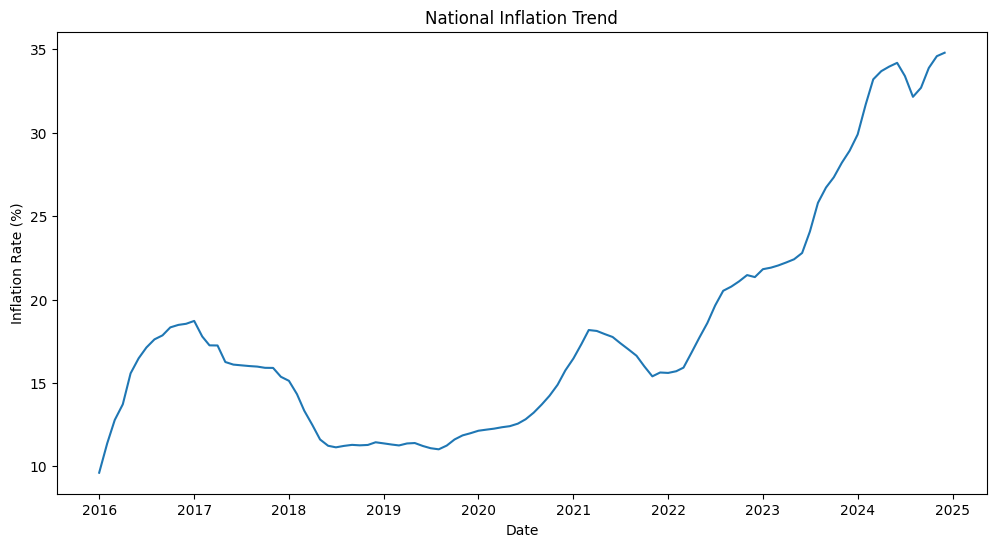

In [21]:
#inflation trend
plt.figure(figsize=(12, 6))
plt.plot(national.index, national['inflation_yoy'])
plt.title("National Inflation Trend")
plt.xlabel("Date")
plt.ylabel("Inflation Rate (%)")


In [24]:
national['inflation_yoy'].autocorr(lag=1)

np.float64(0.9960153772384123)